In [ ]:
# Install PyTorch if needed
!pip install torch torchvision matplotlib numpy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Setup complete!")

PyTorch version: 2.10.0+cpu
Setup complete!


In [ ]:
class Perceptron:
    """
    Simple perceptron: weighted sum + activation.

    Formula: y = activation(w·x + b)
    """
    def __init__(self, input_size):
        self.weights = torch.randn(input_size, requires_grad=True)
        self.bias = torch.randn(1, requires_grad=True)

    def forward(self, x):
        # Weighted sum
        z = torch.dot(x, self.weights) + self.bias
        # Step activation (1 if z > 0, else 0)
        y = (z > 0).float()
        return y

# Test perceptron
perceptron = Perceptron(input_size=3)
x = torch.tensor([1.0, 2.0, 3.0])
output = perceptron.forward(x)

print("Perceptron Test:")
print(f"  Input: {x}")
print(f"  Weights: {perceptron.weights}")
print(f"  Bias: {perceptron.bias}")
print(f"  Output: {output}")

Perceptron Test:
  Input: tensor([1., 2., 3.])
  Weights: tensor([0.3367, 0.1288, 0.2345], requires_grad=True)
  Bias: tensor([0.2303], requires_grad=True)
  Output: tensor([1.])


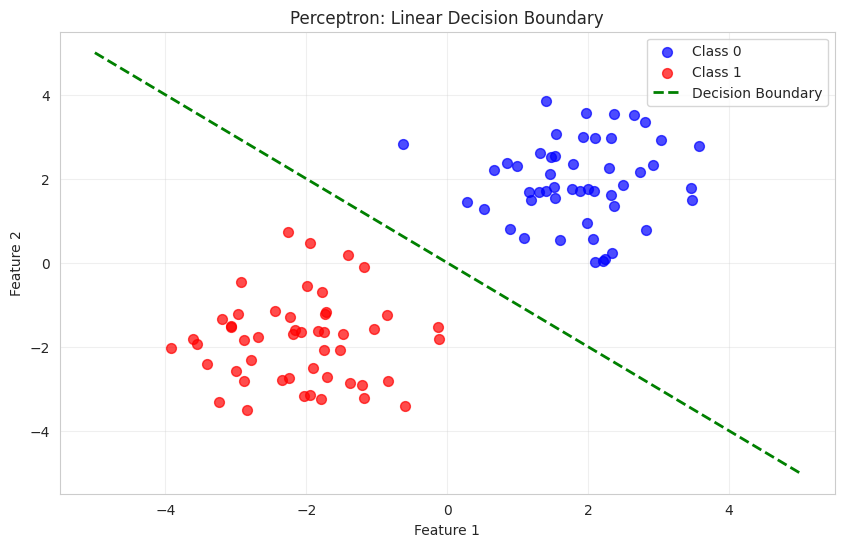

Perceptron can only create LINEAR decision boundaries!


In [ ]:
# Create 2D data (for visualization)
np.random.seed(42)
X_class0 = np.random.randn(50, 2) + np.array([2, 2])
X_class1 = np.random.randn(50, 2) + np.array([-2, -2])
X = np.vstack([X_class0, X_class1])
y = np.hstack([np.zeros(50), np.ones(50)])
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='Class 0', s=50, alpha=0.7)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='Class 1', s=50, alpha=0.7)


# Perceptron decision boundary (random initialization)
w = np.array([1.0, 1.0])
b = 0
x_line = np.linspace(-5, 5, 100)
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, 'g--', linewidth=2, label='Decision Boundary')


plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron: Linear Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Perceptron can only create LINEAR decision boundaries!")

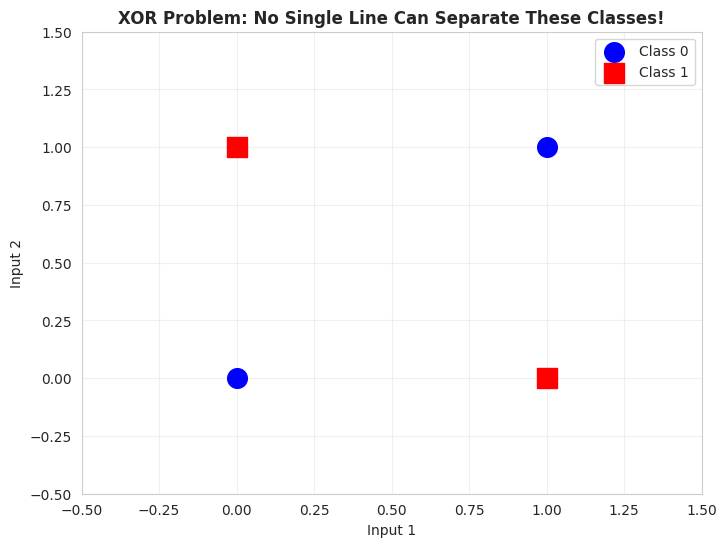

❌ Single perceptron CANNOT solve XOR
✅ Multi-layer network CAN solve XOR!


In [ ]:
# XOR data (NOT linearly separable!)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR labels

plt.figure(figsize=(8, 6))
plt.scatter(X_xor[y_xor==0][:, 0], X_xor[y_xor==0][:, 1],
           c='blue', s=200, label='Class 0', marker='o')
plt.scatter(X_xor[y_xor==1][:, 0], X_xor[y_xor==1][:, 1],
           c='red', s=200, label='Class 1', marker='s')

plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('XOR Problem: No Single Line Can Separate These Classes!', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

print("❌ Single perceptron CANNOT solve XOR")
print("✅ Multi-layer network CAN solve XOR!")

In [ ]:
class MultiLayerNetwork:
    """
    Manual 3-layer network to understand the math.

    Architecture: Input → Hidden1 → Hidden2 → Output
    """
    def __init__(self, input_size, hidden1, hidden2, output_size):
        # Layer 1
        self.W1 = torch.randn(input_size, hidden1, requires_grad=True)
        self.b1 = torch.randn(hidden1, requires_grad=True)

        # Layer 2
        self.W2 = torch.randn(hidden1, hidden2, requires_grad=True)
        self.b2 = torch.randn(hidden2, requires_grad=True)

        # Layer 3
        self.W3 = torch.randn(hidden2, output_size, requires_grad=True)
        self.b3 = torch.randn(output_size, requires_grad=True)

    def forward(self, x):
        # Layer 1: Linear → ReLU
        z1 = torch.matmul(x, self.W1) + self.b1
        a1 = torch.relu(z1)

        # Layer 2: Linear → ReLU
        z2 = torch.matmul(a1, self.W2) + self.b2
        a2 = torch.relu(z2)

        # Layer 3: Linear (output)
        z3 = torch.matmul(a2, self.W3) + self.b3

        return z3

# Create network: 4 inputs → 8 → 4 → 2 outputs
net = MultiLayerNetwork(input_size=4, hidden1=8, hidden2=4, output_size=2)

# Test forward pass
x_test = torch.randn(5, 4)  # Batch of 5 samples
output = net.forward(x_test)

print("Multi-Layer Network Test:")
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"\nLayer 1 weights shape: {net.W1.shape}")
print(f"Layer 2 weights shape: {net.W2.shape}")
print(f"Layer 3 weights shape: {net.W3.shape}")

Multi-Layer Network Test:
  Input shape: torch.Size([5, 4])
  Output shape: torch.Size([5, 2])

Layer 1 weights shape: torch.Size([4, 8])
Layer 2 weights shape: torch.Size([8, 4])
Layer 3 weights shape: torch.Size([4, 2])


In [ ]:
# TODO: Calculate total parameters
# Formula: For each layer: (in × out) + out

layer1_params = None  # Calculate
layer2_params = None  # Calculate
layer3_params = None  # Calculate
total_params = None   # Sum

print(f"Layer 1 parameters: {layer1_params}")
print(f"Layer 2 parameters: {layer2_params}")
print(f"Layer 3 parameters: {layer3_params}")
print(f"Total parameters: {total_params}")

# Verify with actual count
actual_total = net.W1.numel() + net.b1.numel() + net.W2.numel() + net.b2.numel() + net.W3.numel() + net.b3.numel()
print(f"\nActual total: {actual_total}")

Layer 1 parameters: None
Layer 2 parameters: None
Layer 3 parameters: None
Total parameters: None

Actual total: 86


Input: tensor([-2., -1.,  0.,  1.,  2.])
ReLU (manual): tensor([0., 0., 0., 1., 2.])
ReLU (PyTorch): tensor([0., 0., 0., 1., 2.])
ReLU (nn.ReLU): tensor([0., 0., 0., 1., 2.])


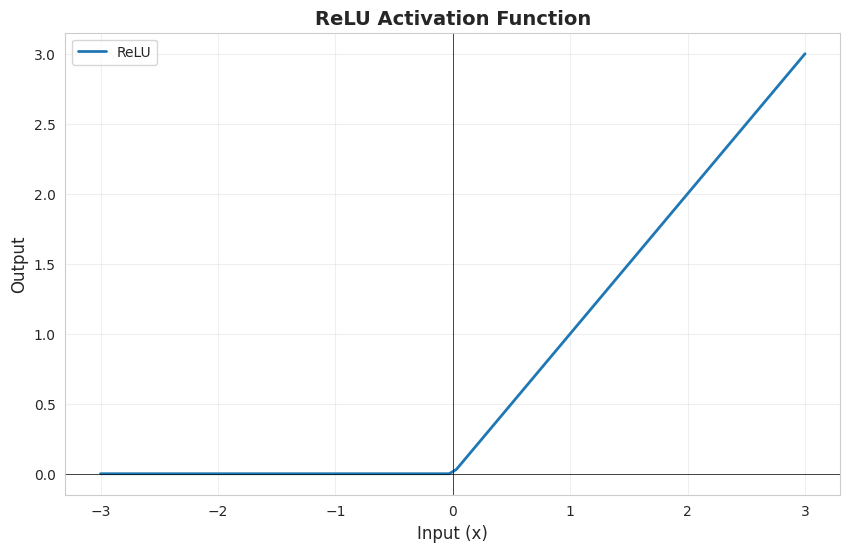

In [ ]:
import torch
import torch.nn.functional as F

# Manual ReLU
def relu_manual(x):
    return torch.maximum(x, torch.tensor(0.0))

# PyTorch ReLU
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"Input: {x}")
print(f"ReLU (manual): {relu_manual(x)}")
print(f"ReLU (PyTorch): {F.relu(x)}")
print(f"ReLU (nn.ReLU): {nn.ReLU()(x)}")

# Visualize
import matplotlib.pyplot as plt
import numpy as np

x_range = np.linspace(-3, 3, 100)
y_relu = np.maximum(0, x_range)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_relu, linewidth=2, label='ReLU')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Input (x)', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.title('ReLU Activation Function', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


Input: tensor([-2., -1.,  0.,  1.,  2.])
Sigmoid (manual): tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
Sigmoid (PyTorch): tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])


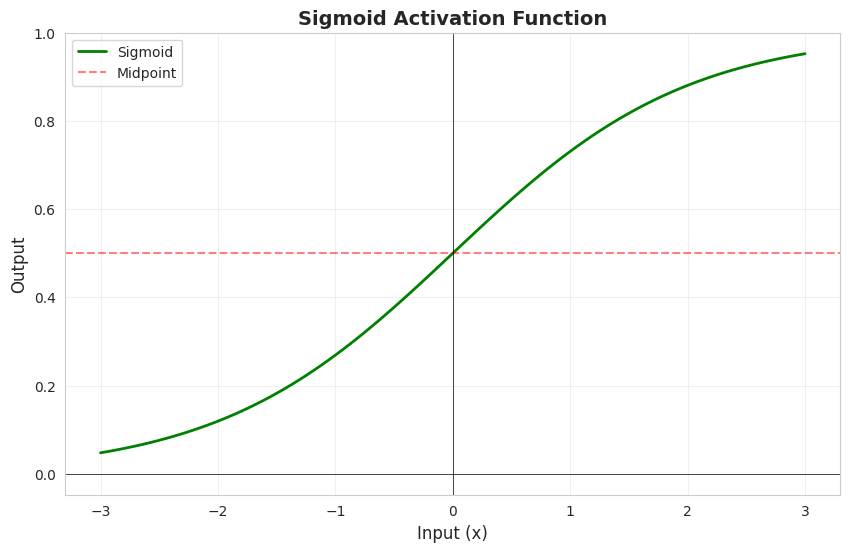

In [ ]:
# Sigmoid
def sigmoid_manual(x):
    return 1 / (1 + torch.exp(-x))

x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"Input: {x}")
print(f"Sigmoid (manual): {sigmoid_manual(x)}")
print(f"Sigmoid (PyTorch): {torch.sigmoid(x)}")

# Visualize
y_sigmoid = 1 / (1 + np.exp(-x_range))

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_sigmoid, linewidth=2, label='Sigmoid', color='green')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Midpoint')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Input (x)', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.title('Sigmoid Activation Function', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


Input: tensor([-2., -1.,  0.,  1.,  2.])
Tanh: tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])


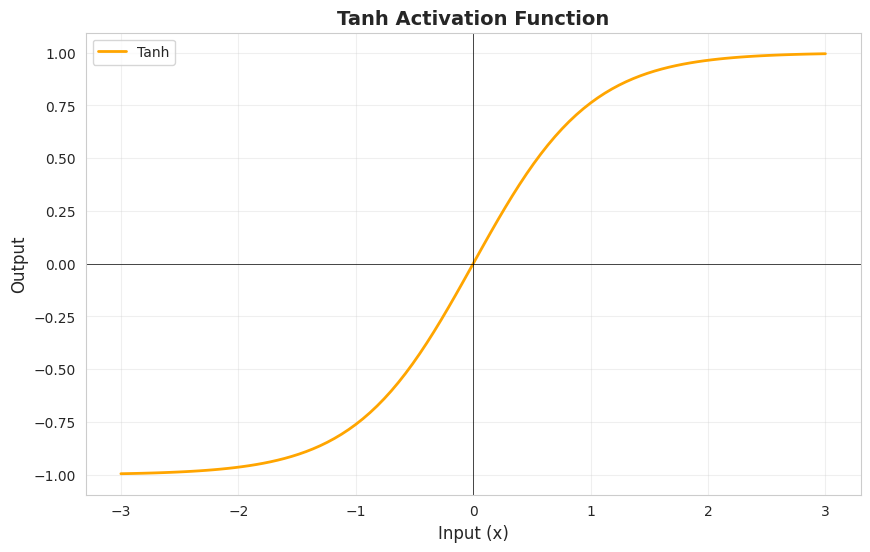

In [ ]:
# Tanh
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"Input: {x}")
print(f"Tanh: {torch.tanh(x)}")

# Visualize
y_tanh = np.tanh(x_range)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_tanh, linewidth=2, label='Tanh', color='orange')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Input (x)', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.title('Tanh Activation Function', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


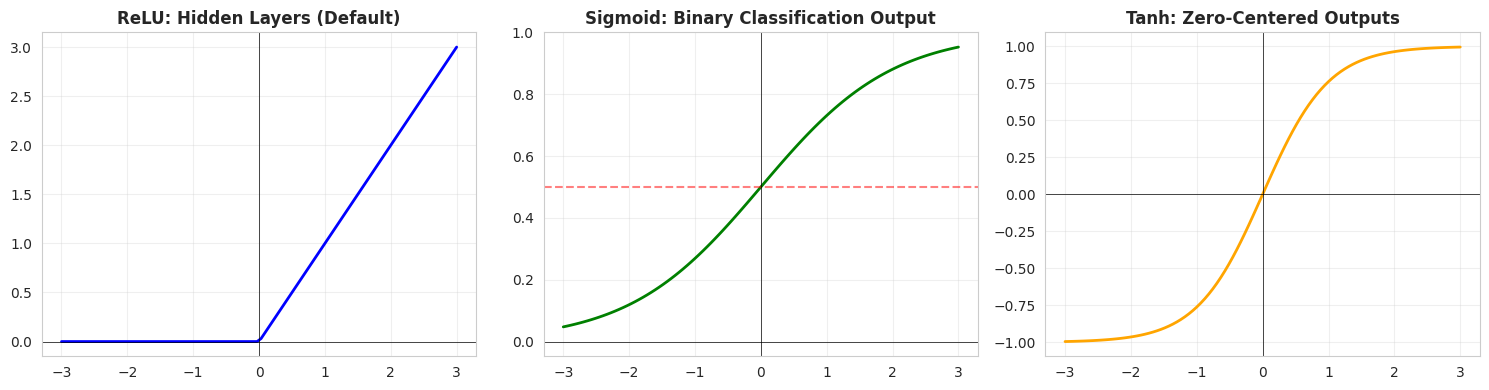


DECISION GUIDE:
- Hidden Layers (most cases): Use ReLU
- Binary Classification Output: Use Sigmoid
- Multi-class Classification Output: Use Softmax (next section)
- Need Zero-Centered: Use Tanh
- RNN/LSTM Gates: Use Sigmoid/Tanh



In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU
axes[0].plot(x_range, y_relu, linewidth=2, color='blue')
axes[0].set_title('ReLU: Hidden Layers (Default)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)

# Sigmoid
axes[1].plot(x_range, y_sigmoid, linewidth=2, color='green')
axes[1].set_title('Sigmoid: Binary Classification Output', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)

# Tanh
axes[2].plot(x_range, y_tanh, linewidth=2, color='orange')
axes[2].set_title('Tanh: Zero-Centered Outputs', fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("""
DECISION GUIDE:
- Hidden Layers (most cases): Use ReLU
- Binary Classification Output: Use Sigmoid
- Multi-class Classification Output: Use Softmax (next section)
- Need Zero-Centered: Use Tanh
- RNN/LSTM Gates: Use Sigmoid/Tanh
""")


In [ ]:
# Softmax
def softmax_manual(x):
    exp_x = torch.exp(x - torch.max(x))  # Numerical stability
    return exp_x / exp_x.sum()

logits = torch.tensor([2.0, 1.0, 0.1])
probs = softmax_manual(logits)

print(f"Logits: {logits}")
print(f"Probabilities: {probs}")
print(f"Sum: {probs.sum()}")  # Should be 1.0


Logits: tensor([2.0000, 1.0000, 0.1000])
Probabilities: tensor([0.6590, 0.2424, 0.0986])
Sum: 1.0000001192092896


True prices: tensor([300000., 250000., 400000.])
Predicted prices: tensor([310000., 240000., 420000.])
MSE Loss: 200000000.00
MSE (PyTorch): 200000000.00


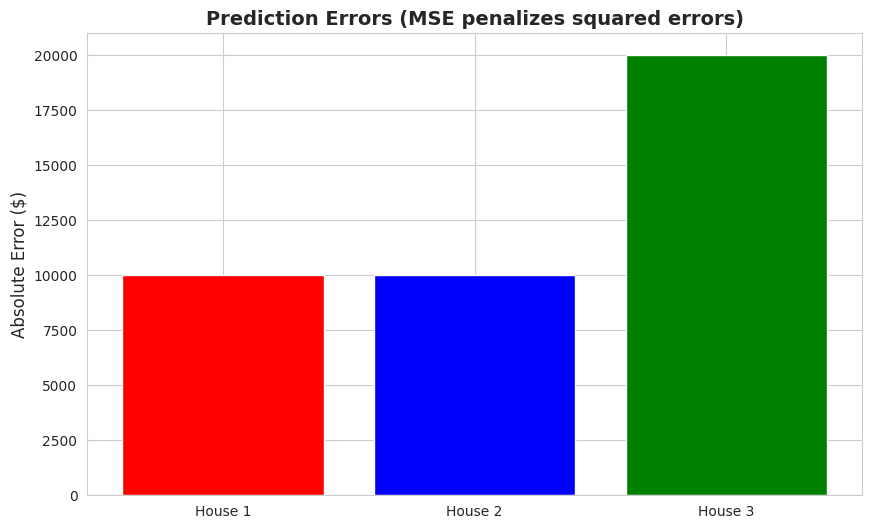

In [ ]:
import torch.nn as nn

# Manual MSE
def mse_manual(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

# Example: House price prediction
y_true = torch.tensor([300000.0, 250000.0, 400000.0])  # Actual prices
y_pred = torch.tensor([310000.0, 240000.0, 420000.0])  # Predicted prices

mse_loss = mse_manual(y_pred, y_true)
print(f"True prices: {y_true}")
print(f"Predicted prices: {y_pred}")
print(f"MSE Loss: {mse_loss.item():.2f}")

# PyTorch MSE
criterion = nn.MSELoss()
loss = criterion(y_pred, y_true)
print(f"MSE (PyTorch): {loss.item():.2f}")

# Visualize error
errors = (y_pred - y_true).abs()
plt.figure(figsize=(10, 6))
plt.bar(['House 1', 'House 2', 'House 3'], errors.numpy(), color=['red', 'blue', 'green'])
plt.ylabel('Absolute Error ($)', fontsize=12)
plt.title('Prediction Errors (MSE penalizes squared errors)', fontsize=14, fontweight='bold')
plt.show()



In [ ]:
# Binary Cross-Entropy
bce_criterion = nn.BCELoss()

# Binary classification example
y_true_binary = torch.tensor([1.0, 0.0, 1.0, 0.0])  # True labels
y_pred_probs = torch.tensor([0.9, 0.2, 0.7, 0.3])   # Predicted probabilities

bce_loss = bce_criterion(y_pred_probs, y_true_binary)
print(f"Binary Cross-Entropy Loss: {bce_loss.item():.4f}")

# Multi-class Cross-Entropy
ce_criterion = nn.CrossEntropyLoss()

# Multi-class example (3 classes, 4 samples)
logits = torch.tensor([
    [2.0, 1.0, 0.1],  # Sample 1
    [0.5, 2.5, 0.3],  # Sample 2
    [1.0, 0.5, 3.0],  # Sample 3
    [3.0, 0.2, 0.5]   # Sample 4
])
labels = torch.tensor([0, 1, 2, 0])  # True class indices

ce_loss = ce_criterion(logits, labels)
print(f"\nCross-Entropy Loss: {ce_loss.item():.4f}")

# Show what the network predicted
probs = torch.softmax(logits, dim=1)
print(f"\nPredicted probabilities:")
print(probs)
print(f"True labels: {labels}")


Binary Cross-Entropy Loss: 0.2605

Cross-Entropy Loss: 0.2418

Predicted probabilities:
tensor([[0.6590, 0.2424, 0.0986],
        [0.1086, 0.8025, 0.0889],
        [0.1112, 0.0674, 0.8214],
        [0.8750, 0.0532, 0.0718]])
True labels: tensor([0, 1, 2, 0])


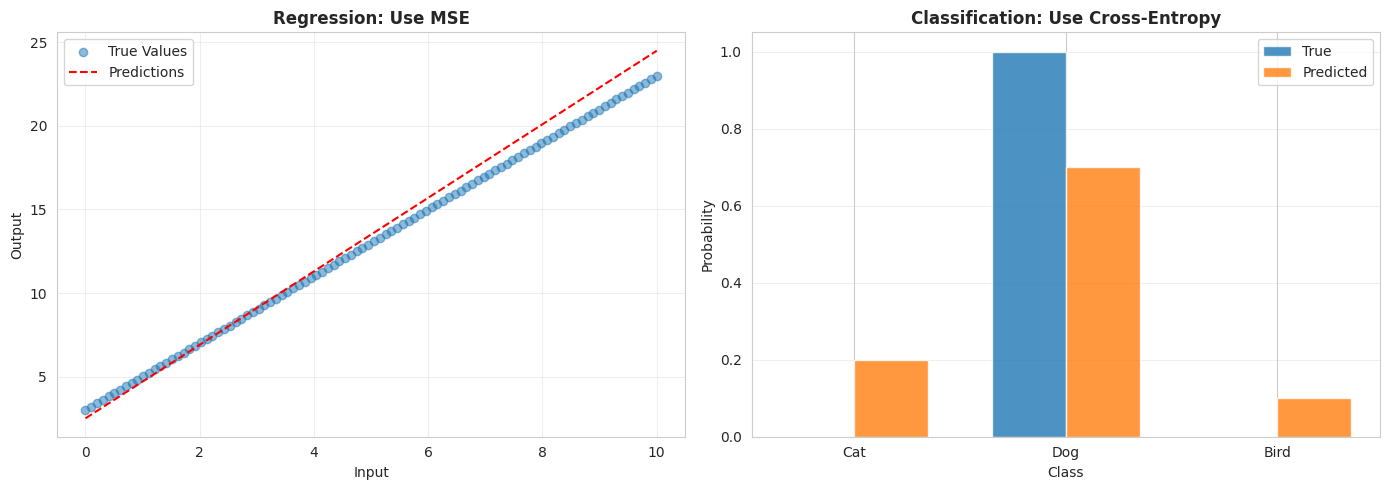


DECISION GUIDE:
┌─────────────────────────────────────────┬──────────────────┐
│ Task Type                               │ Loss Function    │
├─────────────────────────────────────────┼──────────────────┤
│ Regression (continuous values)          │ MSE              │
│ Binary Classification (0/1)             │ BCE              │
│ Multi-class Classification (one-hot)    │ Cross-Entropy    │
│ Multi-label Classification (multiple)   │ BCE per label    │
└─────────────────────────────────────────┴──────────────────┘



In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE for Regression
x_reg = np.linspace(0, 10, 100)
y_true_reg = 2 * x_reg + 3
y_pred_reg = 2.2 * x_reg + 2.5

axes[0].scatter(x_reg, y_true_reg, alpha=0.5, label='True Values')
axes[0].plot(x_reg, y_pred_reg, 'r--', label='Predictions')
axes[0].set_title('Regression: Use MSE', fontweight='bold')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cross-Entropy for Classification
categories = ['Cat', 'Dog', 'Bird']
true_probs = [0, 1, 0]  # True: Dog
pred_probs = [0.2, 0.7, 0.1]  # Predicted probabilities

x_pos = np.arange(len(categories))
width = 0.35

axes[1].bar(x_pos - width/2, true_probs, width, label='True', alpha=0.8)
axes[1].bar(x_pos + width/2, pred_probs, width, label='Predicted', alpha=0.8)
axes[1].set_title('Classification: Use Cross-Entropy', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Probability')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("""
DECISION GUIDE:
┌─────────────────────────────────────────┬──────────────────┐
│ Task Type                               │ Loss Function    │
├─────────────────────────────────────────┼──────────────────┤
│ Regression (continuous values)          │ MSE              │
│ Binary Classification (0/1)             │ BCE              │
│ Multi-class Classification (one-hot)    │ Cross-Entropy    │
│ Multi-label Classification (multiple)   │ BCE per label    │
└─────────────────────────────────────────┴──────────────────┘
""")


In [ ]:
import torch.nn as nn

class MyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Define layers here

    def forward(self, x):
        # Define forward pass here
        return output


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):
    """
    Simple 3-layer network for classification.

    Architecture:
        Input (784) → Hidden1 (128, ReLU) → Hidden2 (64, ReLU) → Output (10)
    """
    def __init__(self, input_size=784, hidden1=128, hidden2=64, num_classes=10):
        super(SimpleClassifier, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        # Layer 1: Linear → ReLU
        x = F.relu(self.fc1(x))

        # Layer 2: Linear → ReLU
        x = F.relu(self.fc2(x))

        # Output layer: Linear (no activation, will use with loss)
        x = self.fc3(x)

        return x

# Create network
model = SimpleClassifier()

# Print architecture
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


SimpleClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 109,386
Trainable parameters: 109,386


In [ ]:
# Create sample input (batch of 32 images, 28×28 pixels)
batch_size = 32
input_data = torch.randn(batch_size, 784)  # Flattened images

print("Input shape:", input_data.shape)

# Forward pass
with torch.no_grad():  # No gradient computation (inference mode)
    output = model(input_data)

print("Output shape:", output.shape)
print("\nRaw output (logits) for first sample:")
print(output[0])

# Convert to probabilities
probs = F.softmax(output, dim=1)
print("\nProbabilities for first sample:")
print(probs[0])
print(f"Sum of probabilities: {probs[0].sum().item():.4f}")

# Get predicted class
predicted_classes = torch.argmax(output, dim=1)
print(f"\nPredicted classes for batch: {predicted_classes[:10]}")


Input shape: torch.Size([32, 784])
Output shape: torch.Size([32, 10])

Raw output (logits) for first sample:
tensor([ 0.0255,  0.0243,  0.0204,  0.0811, -0.1325, -0.1198,  0.0747,  0.0451,
        -0.0022,  0.2036])

Probabilities for first sample:
tensor([0.0999, 0.0998, 0.0994, 0.1056, 0.0853, 0.0864, 0.1050, 0.1019, 0.0972,
        0.1194])
Sum of probabilities: 1.0000

Predicted classes for batch: tensor([9, 3, 7, 6, 3, 0, 3, 8, 3, 0])


In [ ]:
class VerboseNetwork(nn.Module):
    """
    Network that prints shapes at each step for educational purposes.
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x, verbose=False):
        if verbose:
            print(f"Input shape: {x.shape}")

        # Layer 1
        x = self.fc1(x)
        if verbose:
            print(f"After fc1 (Linear): {x.shape}")

        x = F.relu(x)
        if verbose:
            print(f"After ReLU: {x.shape}")
            print(f"  Negative values zeroed: {(x == 0).sum().item()} / {x.numel()}")

        # Layer 2
        x = self.fc2(x)
        if verbose:
            print(f"After fc2 (Linear): {x.shape}")

        x = F.relu(x)
        if verbose:
            print(f"After ReLU: {x.shape}")

        # Output layer
        x = self.fc3(x)
        if verbose:
            print(f"After fc3 (Output): {x.shape}")

        return x

# Test with verbose output
verbose_model = VerboseNetwork()
test_input = torch.randn(1, 784)

print("=" * 50)
print("FORWARD PASS WALKTHROUGH")
print("=" * 50)
output = verbose_model(test_input, verbose=True)


FORWARD PASS WALKTHROUGH
Input shape: torch.Size([1, 784])
After fc1 (Linear): torch.Size([1, 128])
After ReLU: torch.Size([1, 128])
  Negative values zeroed: 71 / 128
After fc2 (Linear): torch.Size([1, 64])
After ReLU: torch.Size([1, 64])
After fc3 (Output): torch.Size([1, 10])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Create synthetic dataset
torch.manual_seed(42)
X_train = torch.randn(1000, 784)
y_train = torch.randint(0, 10, (1000,))

# 2. Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 3. Define model
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNISTClassifier()

# 4. Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training loop
num_epochs = 5

print("Starting training...")
print("=" * 50)

for epoch in range(num_epochs):
    total_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        # Forward pass
        output = model(data)
        loss = criterion(output, target)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("=" * 50)
print("Training complete!")

# 6. Inference
model.eval()
with torch.no_grad():
    test_input = torch.randn(1, 784)
    test_output = model(test_input)
    predicted_class = torch.argmax(test_output, dim=1)

    print(f"\nTest input shape: {test_input.shape}")
    print(f"Predicted class: {predicted_class.item()}")
    print(f"Class probabilities:")
    probs = F.softmax(test_output, dim=1)
    for i, p in enumerate(probs[0]):
        print(f"  Class {i}: {p.item():.4f}")


Starting training...
Epoch [1/5], Loss: 2.3112
Epoch [2/5], Loss: 2.0881
Epoch [3/5], Loss: 1.6070
Epoch [4/5], Loss: 0.6898
Epoch [5/5], Loss: 0.1441
Training complete!

Test input shape: torch.Size([1, 784])
Predicted class: 2
Class probabilities:
  Class 0: 0.0768
  Class 1: 0.0045
  Class 2: 0.2758
  Class 3: 0.0448
  Class 4: 0.0968
  Class 5: 0.1409
  Class 6: 0.1062
  Class 7: 0.0043
  Class 8: 0.1698
  Class 9: 0.0802


In [ ]:
Calculate the total number of trainable parameters in this network:
Linear(10, 20)
Linear(20, 5)
Include both weights and biases. Enter your answer as a number: